# Create SWOT files on datarmor

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import browse_swot_2km, add_grid_metrics,rotate_ggd

## SWOT DATA

In [2]:
dfs = browse_swot_2km().reset_index()
dss = xr.open_dataset(dfs.file.iloc[0])
dss = add_grid_metrics(dss)
dss['f'] =   2 * 2 * np.pi / 86164.1 * np.sin(dss.latitude * np.pi / 180)
g=9.81

dss['dx_fromduacsv'] = dss.f/g * dss.duacs_speed_meridional
dss['dy_fromduacsv'] = -dss.f/g * dss.duacs_speed_zonal

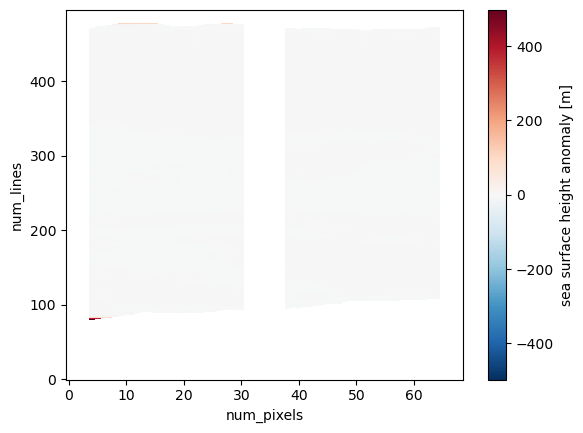

In [3]:
dss.duacs_ssha_karin_2_calibrated.plot()

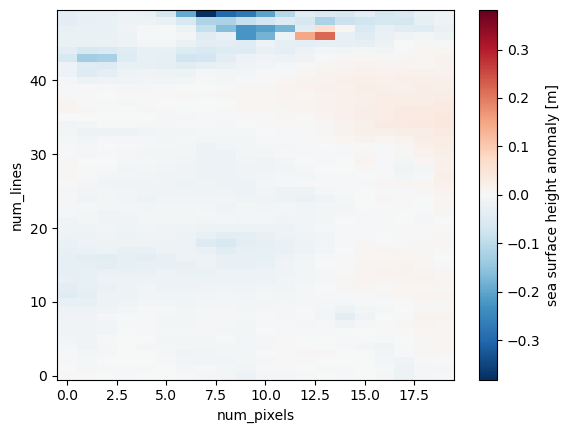

In [4]:
# Define sub_grid for test
sla = dss.duacs_ssha_karin_2_calibrated.isel(num_lines = slice(150, 200), num_pixels = slice(10, 30))
dss_dx = dss['dx_fromduacsv'].isel(num_lines = slice(150, 200), num_pixels = slice(10, 30))
dss_dy = dss['dy_fromduacsv'].isel(num_lines = slice(150, 200), num_pixels = slice(10, 30))
dss_vort = dss['duacs_relative_vorticity'].isel(num_lines = slice(150, 200), num_pixels = slice(10, 30))
f = dss.f.isel(num_lines = slice(150, 200), num_pixels = slice(10, 30))
sla.plot()

_____________
# Pre-test
## Stencil 9pts kernel filter inspired from products routine
- for to apply : https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.generic_filter.html#scipy.ndimage.generic_filter

0.330952380952381 1.2071428571428573


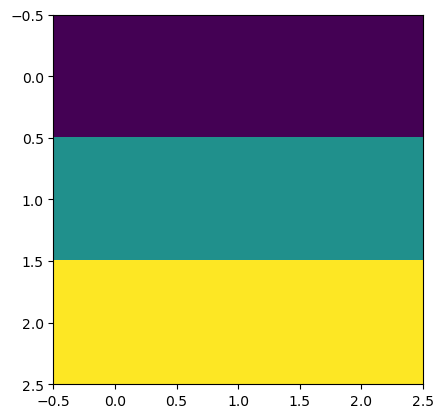

In [5]:
def stencil_diff(image, dir_='y'):
    from scipy.ndimage import convolve
    st = -np.array([[1/280, -4/105, 1/5], [4/5, 0, -4/5], [-1/5, 4/105, -1/280]])
    if dir_ == 'y': st = st.T
    return image.dot(st.flatten())
    
image = np.array([[1, 1, 1], [2, 2, 2], [3, 3, 3]])
print(stencil_diff(image.flatten(), dir_='x'), stencil_diff(image.flatten(), dir_='y'))
plt.imshow(np.array([[1, 1, 1], [2, 2, 2], [3, 3, 3]]))

## Fitting kernel

-0.005592081632653051


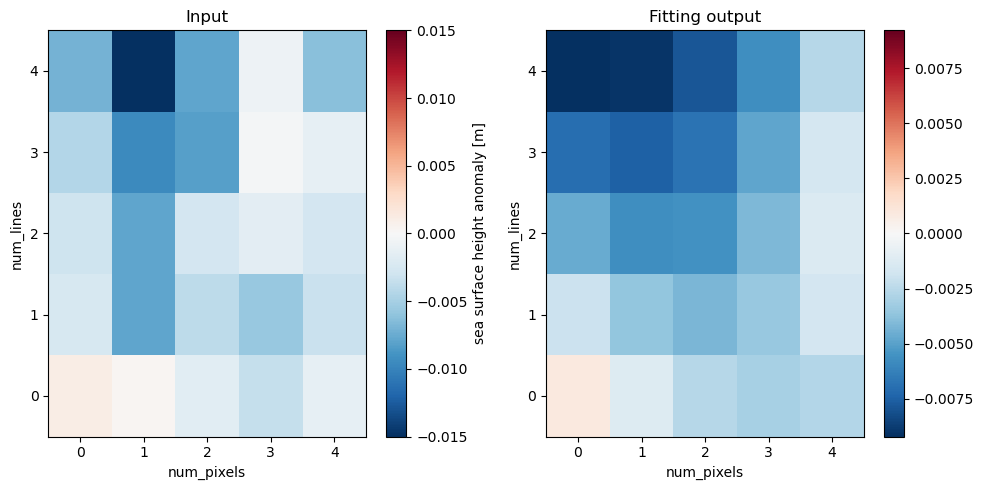

In [6]:
# test fit on an image (not direct application)
def fitting(image): 
    n=int(np.sqrt(image.shape[0]))
    if isinstance(image, xr.DataArray): image = image.values
    x = np.arange(n)
    y = np.arange(n)
    X, Y = np.meshgrid(x, y, copy=False)
    X, Y = np.meshgrid(x, y, copy=False)

    X = X.flatten()
    Y = Y.flatten()

    A = np.array([X*0+1, X, Y, X**2, X**2*Y, X**2*Y**2, Y**2, X*Y**2, X*Y]).T

    coeff, r, rank, s = np.linalg.lstsq(A, image)
    
    Zm = A.dot(coeff)
    fitted_image = np.reshape(Zm, (n,n))
    return fitted_image

def fitting_kernel(image):
    fitted_image = fitting(image)
    lx, ly = fitted_im.shape
    return float(fitted_image[lx//2, ly//2])

def apply_fitting_kernel_filter(image, npts):
    return generic_filter(image, fitting_kernel, [npts, npts]) 

im_ = sla.isel(num_lines = slice(0,5), num_pixels = slice(0, 5))#.values
fitted_im = xr.DataArray(fitting(np.array(im_).flatten()), dims = im_.dims)
fig, axs =plt.subplots(1,2, figsize=(10, 5))
im_.plot(ax=axs[0])
fitted_im.plot(ax=axs[1])
axs[0].set_title('Input')
axs[1].set_title('Fitting output')
print(fitting_kernel(np.array(im_).flatten()))
fig.tight_layout()

_________
# Apply filters to compute dx, dy, dxx, dyy, dxy

In [7]:
# Stencil method
def apply_stencil_diff_filter(image, var):
    from scipy.ndimage import convolve
    assert var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'], "var must be in 'dx', 'dy', 'dxx', 'dyy', 'dxy'"
    image = image.interpolate_na('num_pixels').interpolate_na('num_lines')
    
    stx = np.array([[1/280, -4/105, 1/5], [4/5, 0, -4/5], [-1/5, 4/105, -1/280]])
    sty = stx.T

    if var == 'dx' : output = convolve(image, stx)
    if var == 'dy' : output = convolve(image, sty)
    if var == 'dxx' : output = convolve(convolve(image, stx), stx)
    if var == 'dyy' : output = convolve(convolve(image, sty), sty)
    if var == 'dxy' : output = convolve(convolve(image, stx), sty)
    
    return xr.DataArray(output, dims=image.dims)

# Fitting kernel
def fitting_coeff(image, var): 
    """
    var must be in 'cste', 'dx', 'dy', 'dxx', 'dyy', 'dxy'
    """
    meaning_coeff = {'cste':0, 'dx':1, 'dy':2, 'dxx':3, 'dyy':4, 'dxy':5}
    assert var in meaning_coeff.keys(), "var must be in 'cste', 'dx', 'dy', 'dxx', 'dyy', 'dxy'"
    n=int(np.sqrt(image.shape[0]))
    if isinstance(image, xr.DataArray): image = image.values
    x = np.arange(n)
    y = np.arange(n)
    X, Y = np.meshgrid(x, y, copy=False)
    X, Y = np.meshgrid(x, y, copy=False)

    X = X.flatten()
    Y = Y.flatten()

    A = np.array([X*0+1, X, Y, X**2, Y**2, X*Y**2, X*Y]).T

    coeff, r, rank, s = np.linalg.lstsq(A, image)
    return coeff[meaning_coeff[var]]

def apply_fitting_kernel_filter(swot_image, npts, var):
    from scipy.ndimage import generic_filter
    swot_image = swot_image.interpolate_na('num_pixels').interpolate_na('num_lines')
    return xr.DataArray(generic_filter(swot_image, fitting_coeff, size=[npts, npts], extra_keywords = {'var':var}), dims=swot_image.dims)
 

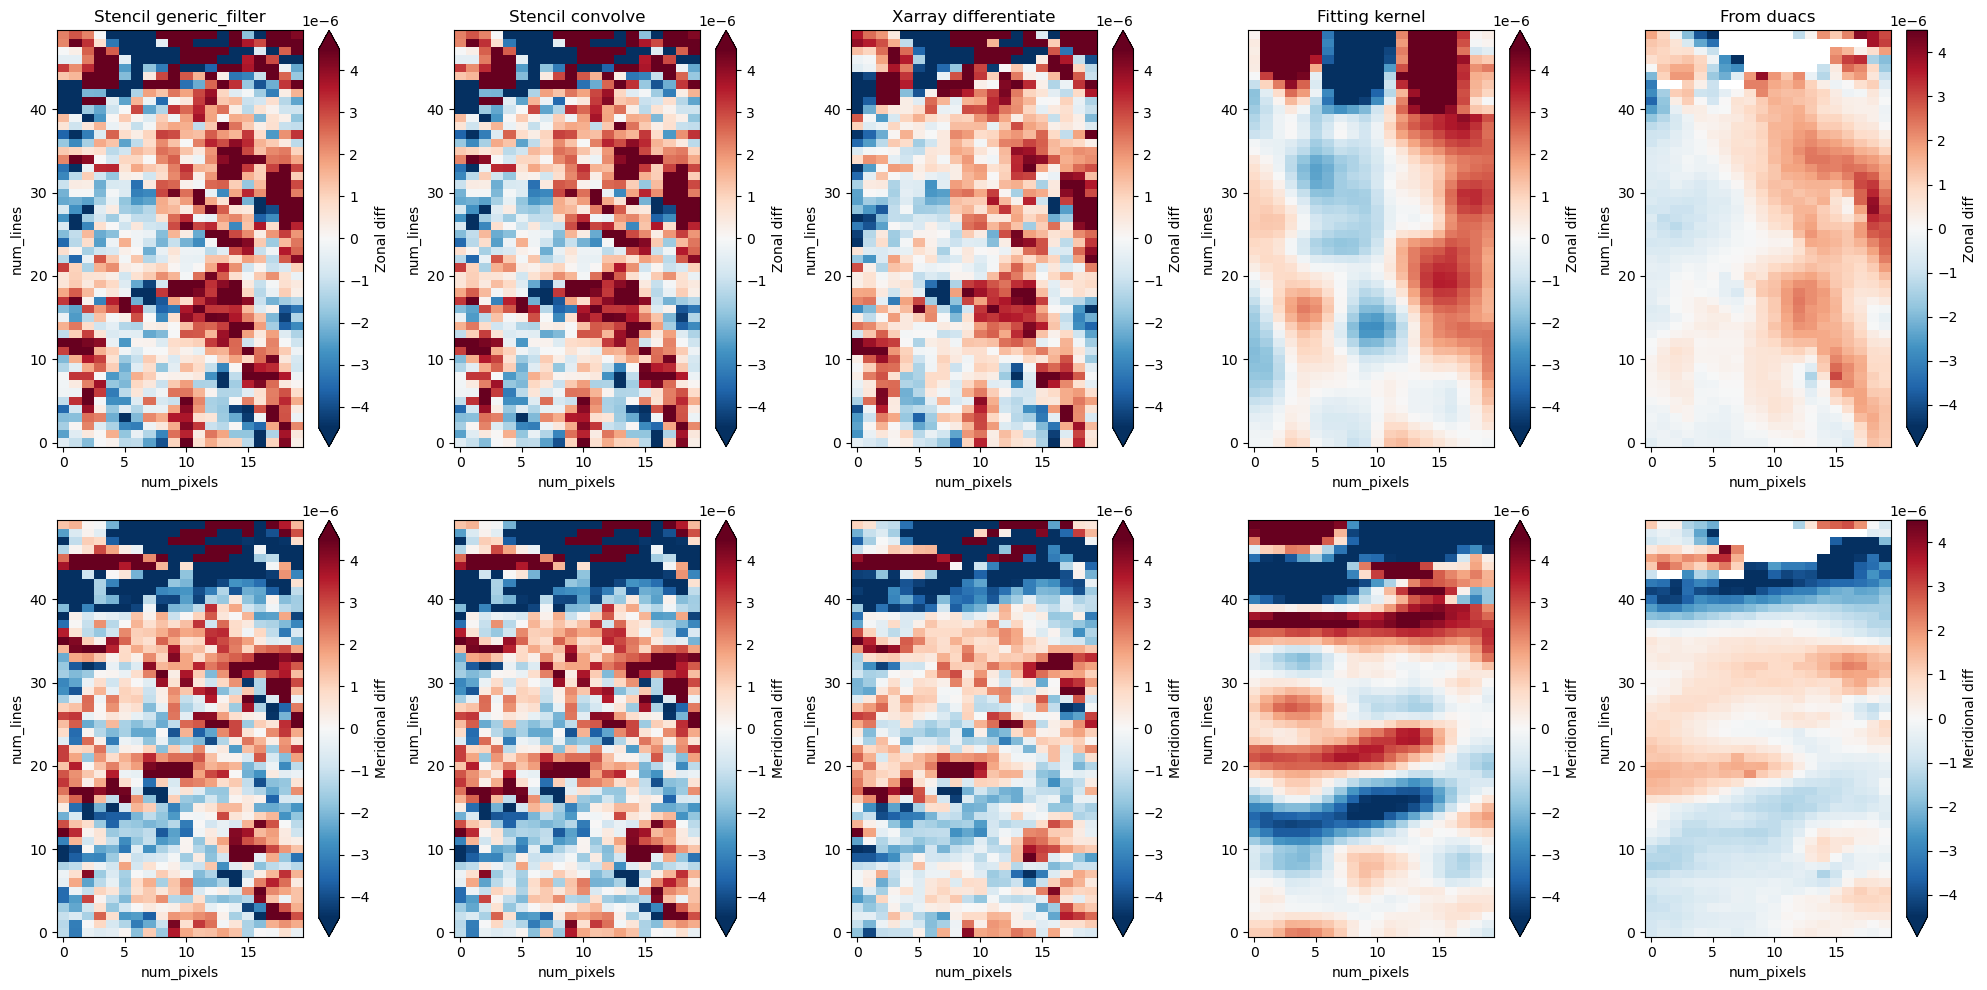

In [10]:
fig, axs = plt.subplots(2, 5, figsize=(20, 10))
dx, dy = 2000., 2000.
g=9.81
vmax=4.5e-6
# Stencil a la mano
(apply_stencil_diff_alamano(sla, dir_='x')/dx).assign_attrs({'long_name':'Zonal diff'}).plot(ax=axs[0, 0], vmax=vmax)
(apply_stencil_diff_alamano(sla, dir_='y')/dy).assign_attrs({'long_name':'Meridional diff'}).plot(ax=axs[1, 0], vmax=vmax)
axs[0, 0].set_title('Stencil generic_filter')

#Stencil convolve
(apply_stencil_diff_filter(sla, var='dx')/dx).assign_attrs({'long_name':'Zonal diff'}).plot(ax=axs[0, 1], vmax=vmax)
(apply_stencil_diff_filter(sla, var='dy')/dy).assign_attrs({'long_name':'Meridional diff'}).plot(ax=axs[1, 1], vmax=vmax)
axs[0, 1].set_title('Stencil convolve')

# xarray differentiate
(sla.differentiate('num_pixels')/dx).assign_attrs({'long_name':'Zonal diff'}).plot(ax=axs[0, 2], vmax=vmax)
(sla.differentiate('num_lines')/dy).assign_attrs({'long_name':'Meridional diff'}).plot(ax=axs[1, 2], vmax=vmax)
axs[0,2].set_title('Xarray differentiate')


#Fitting kernel
(apply_fitting_kernel_filter(sla, 13, 'dx')/dx).assign_attrs({'long_name':'Zonal diff'}).plot(ax=axs[0,3], vmax=vmax)
(apply_fitting_kernel_filter(sla, 13, 'dy')/dy).assign_attrs({'long_name':'Meridional diff'}).plot(ax=axs[1, 3], vmax=vmax)
axs[0, 3].set_title('Fitting kernel')


#Fitting kernel
dss_dx.assign_attrs({'long_name':'Zonal diff'}).plot(ax=axs[0,4], vmax=vmax)
dss_dy.assign_attrs({'long_name':'Meridional diff'}).plot(ax=axs[1, 4], vmax=vmax)
axs[0, 4].set_title('From duacs')


fig.tight_layout()

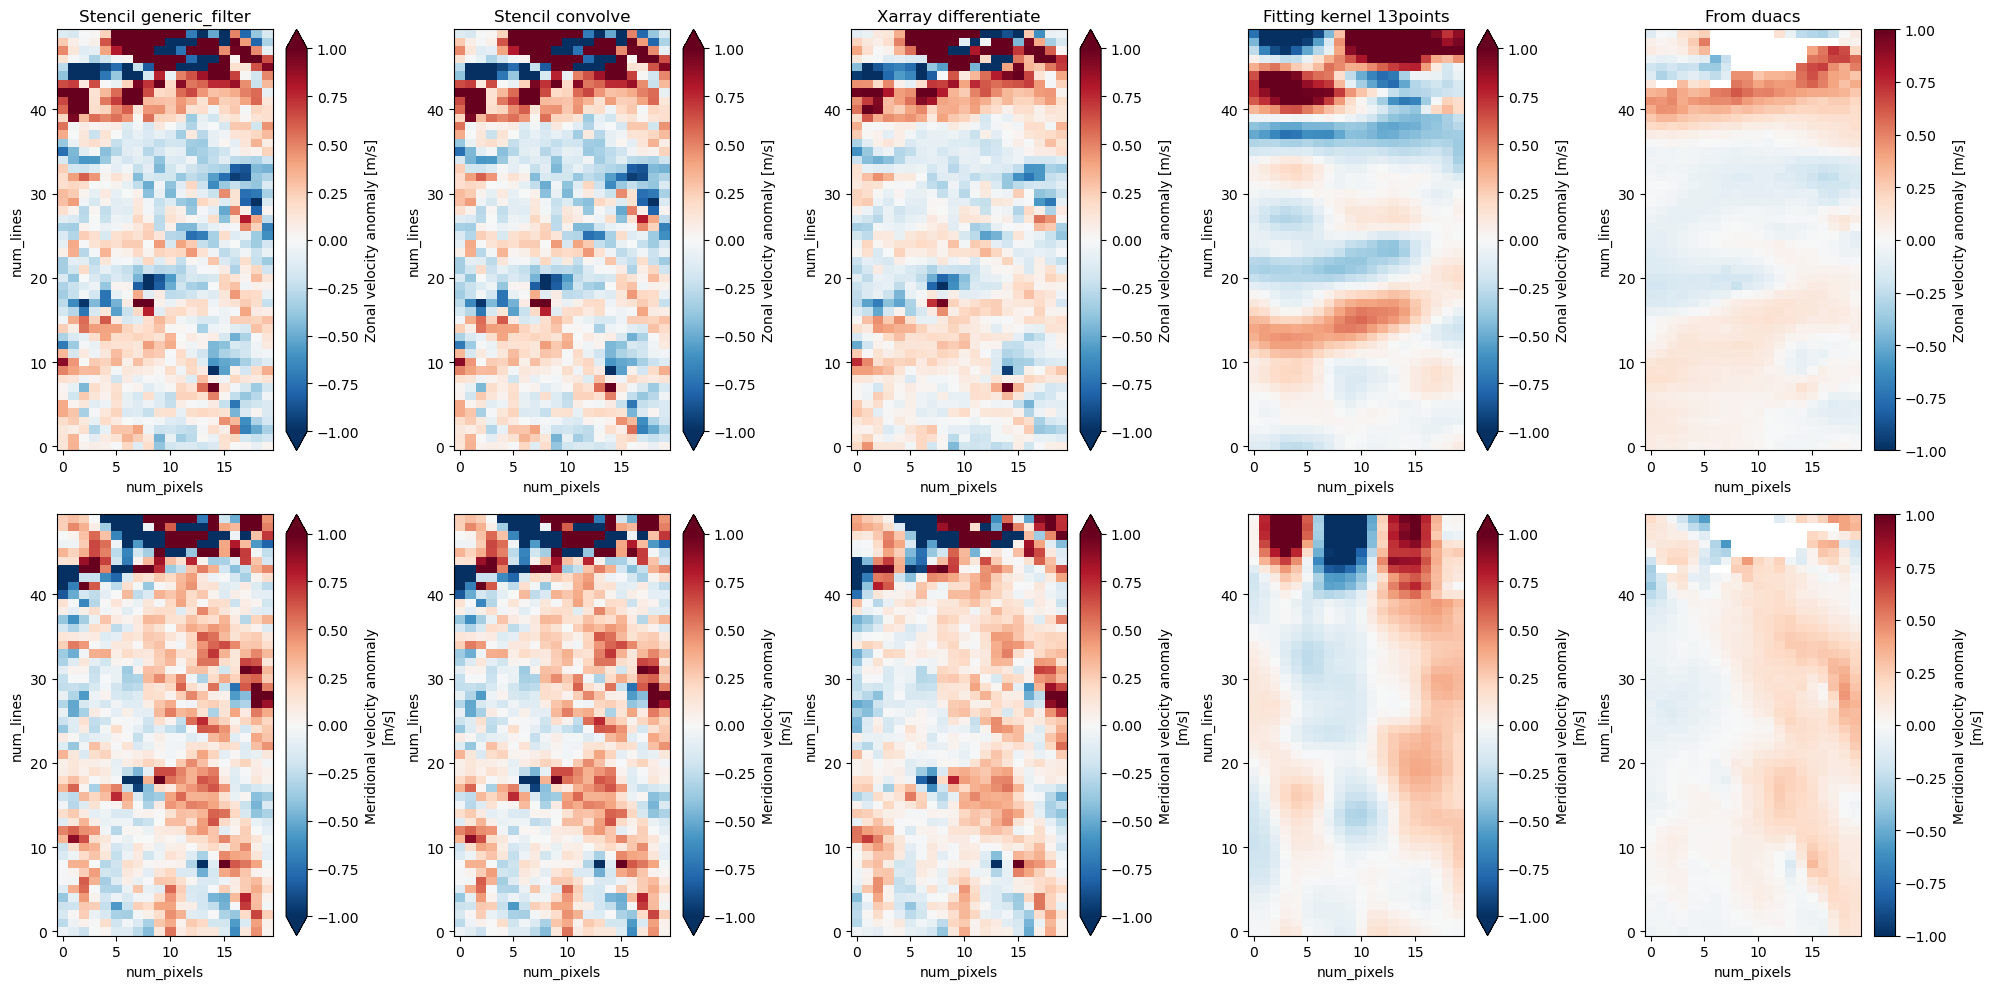

In [11]:
fig, axs = plt.subplots(2, 5, figsize=(20, 10))
dx, dy = 2000., 2000.
g=9.81
vmax=1
# Stencil a la mano
(-g/f*apply_stencil_diff_alamano(sla, dir_='y')/dy).assign_attrs({'long_name':'Zonal velocity anomaly [m/s]'}).plot(ax=axs[0, 0], vmax=vmax)
(g/f*apply_stencil_diff_alamano(sla, dir_='x')/dx).assign_attrs({'long_name':'Meridional velocity anomaly [m/s]'}).plot(ax=axs[1, 0], vmax=vmax)
axs[0, 0].set_title('Stencil generic_filter')

#Stencil convolve
(-g/f*apply_stencil_diff_filter(sla, var='dy')/dy).assign_attrs({'long_name':'Zonal velocity anomaly [m/s]'}).plot(ax=axs[0, 1], vmax=vmax)
(g/f*apply_stencil_diff_filter(sla, var='dx')/dx).assign_attrs({'long_name':'Meridional velocity anomaly [m/s]'}).plot(ax=axs[1, 1], vmax=vmax)
axs[0, 1].set_title('Stencil convolve')

# xarray differentiate
(-g/f*sla.differentiate('num_lines')/dy).assign_attrs({'long_name':'Zonal velocity anomaly [m/s]'}).plot(ax=axs[0, 2], vmax=vmax)
(g/f*sla.differentiate('num_pixels')/dx).assign_attrs({'long_name':'Meridional velocity anomaly [m/s]'}).plot(ax=axs[1, 2], vmax=vmax)
axs[0,2].set_title('Xarray differentiate')


#Fitting kernel
(-g/f*apply_fitting_kernel_filter(sla, 13, var='dy')/dy).assign_attrs({'long_name':'Zonal velocity anomaly [m/s]'}).plot(ax=axs[0, 3], vmax=vmax)
(g/f*apply_fitting_kernel_filter(sla,13, var='dx')/dx).assign_attrs({'long_name':'Meridional velocity anomaly [m/s]'}).plot(ax=axs[1, 3], vmax=vmax)
axs[0, 3].set_title('Fitting kernel 13points')


#Duacs
(-g/f*dss_dy).assign_attrs({'long_name':'Zonal velocity anomaly [m/s]'}).plot(ax=axs[0,4], vmax=vmax)
(g/f*dss_dx).assign_attrs({'long_name':'Meridional velocity anomaly [m/s]'}).plot(ax=axs[1, 4], vmax=vmax)
axs[0, 4].set_title('From duacs')


fig.tight_layout()

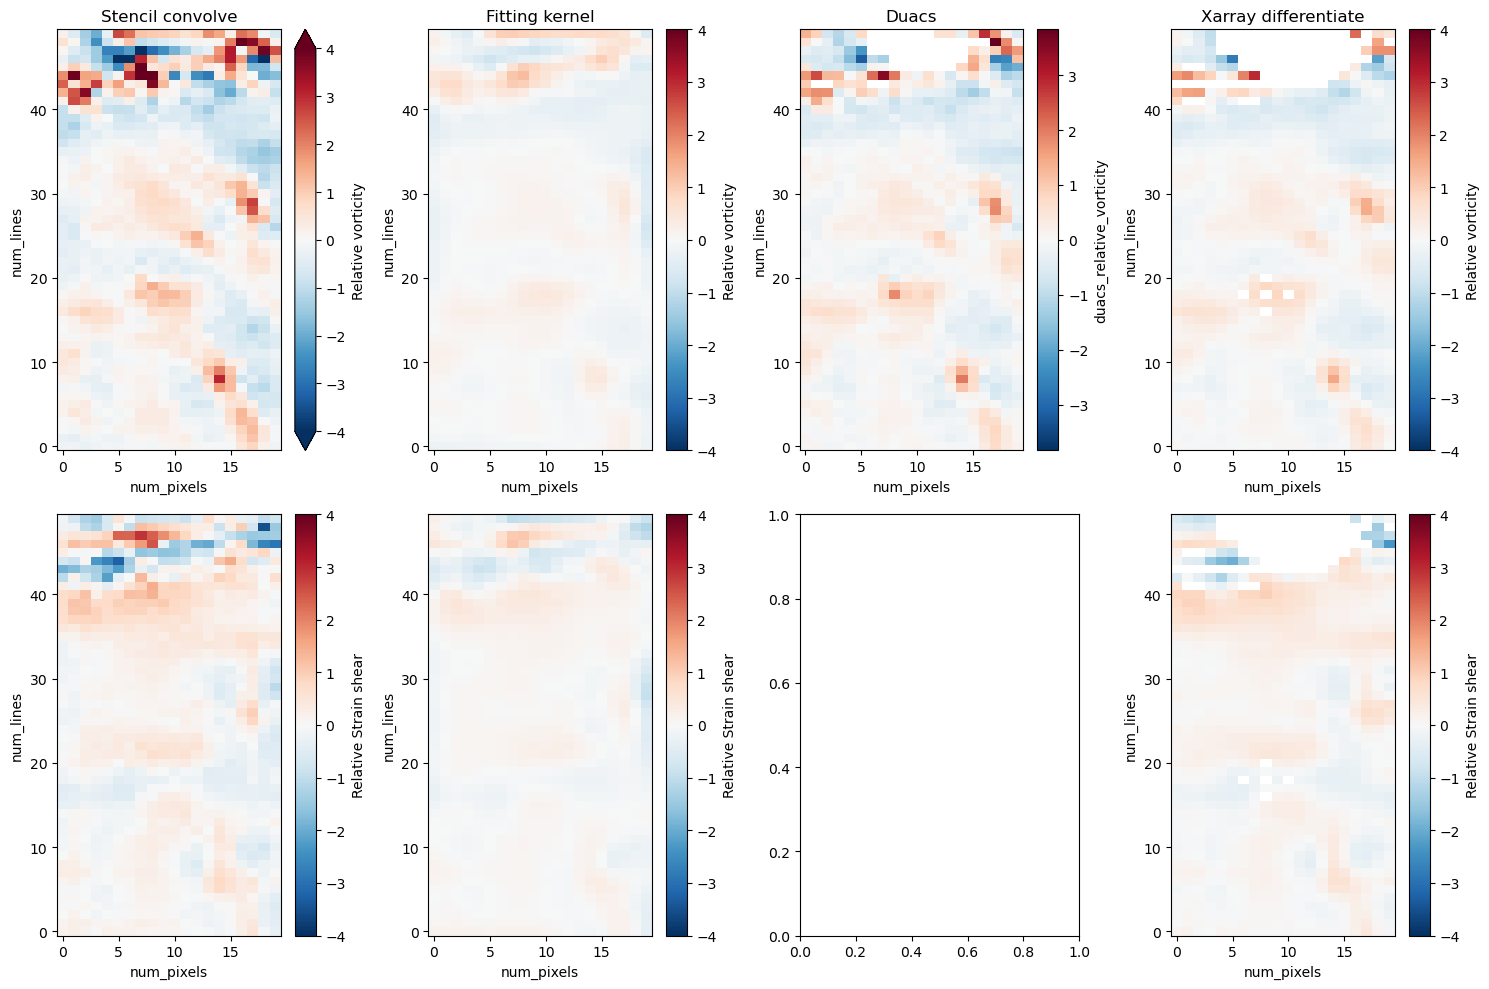

In [91]:
fig, axs = plt.subplots(2, 4, figsize=(15, 10))
dx, dy = 2000., 2000.
vmax = 4
#Stencil convolve
dxx = apply_stencil_diff_filter(sla, var='dxx')/dx/dx*g/(f**2)
dyy = apply_stencil_diff_filter(sla, var='dyy')/dy/dy*g/(f**2)
(dxx+dyy).assign_attrs({'long_name':'Relative vorticity'}).plot(ax=axs[0, 0], vmax=vmax)
(dxx-dyy).assign_attrs({'long_name':'Relative Strain shear'}).plot(ax=axs[1, 0], vmax=vmax)
axs[0, 0].set_title('Stencil convolve')

#Fitting kernel
dxx = apply_fitting_kernel_filter(sla, 5, var='dxx')/dx/dx*g/(f**2)
dyy = apply_fitting_kernel_filter(sla, 5, var='dyy')/dy/dy*g/(f**2)
(dxx+dyy).assign_attrs({'long_name':'Relative vorticity'}).plot(ax=axs[0, 1], vmax=vmax)
(dxx-dyy).assign_attrs({'long_name':'Relative Strain shear'}).plot(ax=axs[1, 1], vmax=vmax)
axs[0, 1].set_title('Fitting kernel')

#Duacs
(dss_vort).plot(ax=axs[0, 2])
axs[0, 2].set_title('Duacs')

#xarray diff
# xarray differentiate
dxx = (sla.differentiate('num_pixels').differentiate('num_pixels')/dx/dx)*g/(f**2)
dyy = (sla.differentiate('num_lines').differentiate('num_lines')/dy/dy)*g/(f**2)
(dxx+dyy).assign_attrs({'long_name':'Relative vorticity'}).plot(ax=axs[0, 3], vmax=vmax)
(dxx-dyy).assign_attrs({'long_name':'Relative Strain shear'}).plot(ax=axs[1, 3], vmax=vmax)
axs[0,3].set_title('Xarray differentiate')

fig.tight_layout()